# Cuaderno 4.2 -- Funciones de separación

El propósito de este cuaderno es entender cómo una red neuronal con dos capas ocultas construye funciones más complicadas recortando y recombinando las representaciones en las variables ocultas intermedias.

Trabaja a través de las celdas de abajo, ejecutando cada celda a su vez. En varios lugares verás las palabras "TAREA". Sigue las instrucciones en estos lugares y haz predicciones sobre lo que va a suceder o escribe código para completar las funciones.

Contáctame en udlbookmail@gmail.com si encuentras algún error o tienes alguna sugerencia.

In [1]:
# Importa la librería de matemáticas
import numpy as np
# Importa la librería de trazado
import matplotlib.pyplot as plt

In [2]:
# Define la función de Unidad Lineal Rectificada (ReLU)
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [3]:
# Define una red neuronal profunda con una entrada, una salida, dos capas ocultas y tres unidades ocultas (ecuaciones 4.7-4.9)
# Para facilitar esto, almacenamos los parámetros en ndarrays, por lo que phi_0 = phi[0] y psi_3,3 = psi[3,3], etc.
def shallow_1_1_3_3(x, activation_fn, phi, psi, theta):

  # TAREA -- Escribe esta función
  # Reemplaza el código esqueleto de abajo.

  # RESPUESTA
  # Preactivaciones en la capa 1 (términos entre paréntesis en la ecuación 4.7)
  layer1_pre_1 = theta[1,0] + theta[1,1] * x ;
  layer1_pre_2 = theta[2,0] + theta[2,1] * x ;
  layer1_pre_3 = theta[3,0] + theta[3,1] * x ;

  # Funciones de activación (resto de la ecuación 4.7)
  h1 = activation_fn(layer1_pre_1)
  h2 = activation_fn(layer1_pre_2)
  h3 = activation_fn(layer1_pre_3)

  # Preactivaciones en la capa 2 (términos entre paréntesis en la ecuación 4.8)
  layer2_pre_1 = psi[1,0] + psi[1,1] * h1 + psi[1,2] * h2 + psi[1,3] * h3;
  layer2_pre_2 = psi[2,0] + psi[2,1] * h1 + psi[2,2] * h2 + psi[2,3] * h3;
  layer2_pre_3 = psi[3,0] + psi[3,1] * h1 + psi[3,2] * h2 + psi[3,3] * h3;

  # Funciones de activación (resto de la ecuación 4.8)
  h1_prime = activation_fn(layer2_pre_1)
  h2_prime = activation_fn(layer2_pre_2)
  h3_prime = activation_fn(layer2_pre_3)

  # Salidas ponderadas por phi (tres últimos términos de la ecuación 4.9)
  phi1_h1_prime = phi[1] * h1_prime ;
  phi2_h2_prime = phi[2] * h2_prime ;
  phi3_h3_prime = phi[3] * h3_prime ;

  # Combina la activación ponderada y añade el desplazamiento y (sumando términos de la ecuación 4.9)
  y = phi[0] + phi1_h1_prime + phi2_h2_prime + phi3_h3_prime ;


  # Devuelve todo lo que hemos calculado
  return y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime

In [4]:
# # Trazar red neuronal de dos capas como en la figura 4.5
def plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime):

    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,layer2_pre_1,'r-'); ax[0,0].set_ylabel('$\\psi_{10}+\\psi_{11}h_{1}+\\psi_{12}h_{2}+\\psi_{13}h_3$')
    ax[0,1].plot(x,layer2_pre_2,'b-'); ax[0,1].set_ylabel('$\\psi_{20}+\\psi_{21}h_{1}+\\psi_{22}h_{2}+\\psi_{23}h_3$')
    ax[0,2].plot(x,layer2_pre_3,'g-'); ax[0,2].set_ylabel('$\\psi_{30}+\\psi_{31}h_{1}+\\psi_{32}h_{2}+\\psi_{33}h_3$')
    ax[1,0].plot(x,h1_prime,'r-'); ax[1,0].set_ylabel("$h_{1}^{'}$")
    ax[1,1].plot(x,h2_prime,'b-'); ax[1,1].set_ylabel("$h_{2}^{'}$")
    ax[1,2].plot(x,h3_prime,'g-'); ax[1,2].set_ylabel("$h_{3}^{'}$")
    ax[2,0].plot(x,phi1_h1_prime,'r-'); ax[2,0].set_ylabel("$\\phi_1 h_{1}^{'}$")
    ax[2,1].plot(x,phi2_h2_prime,'b-'); ax[2,1].set_ylabel("$\\phi_2 h_{2}^{'}$")
    ax[2,2].plot(x,phi3_h3_prime,'g-'); ax[2,2].set_ylabel("$\\phi_3 h_{3}^{'}$")

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel('Entrada, $x$');
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(x,y)
    ax.set_xlabel('Entrada, $x$'); ax.set_ylabel('Salida, $y$')
    ax.set_xlim([0,1]);ax.set_ylim([-1,1])
    ax.set_aspect(0.5)
    plt.show()

Ahora definamos los parámetros y visualicemos la red

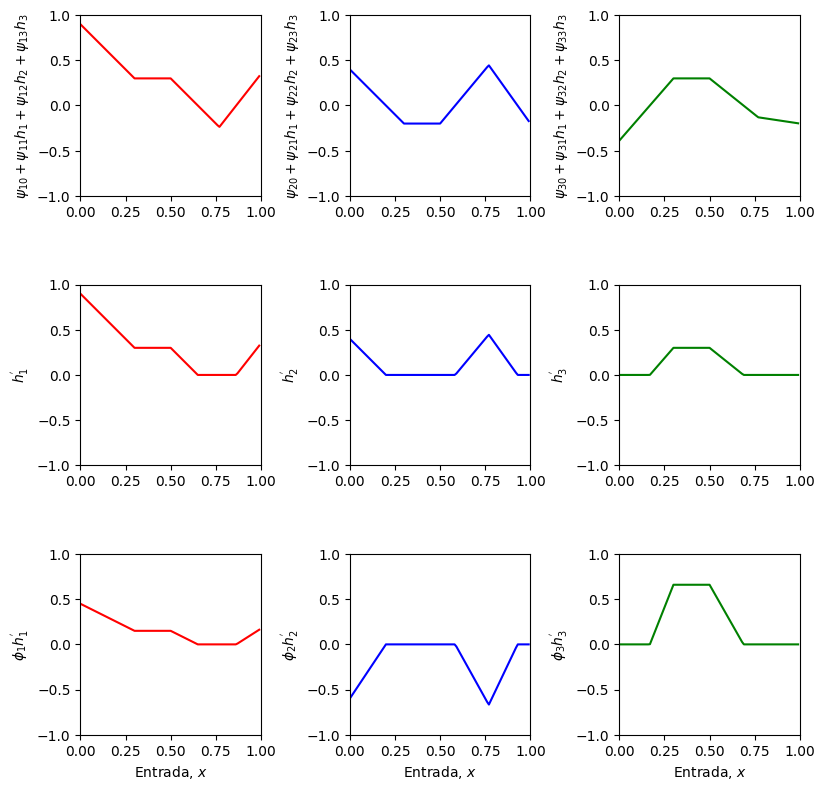

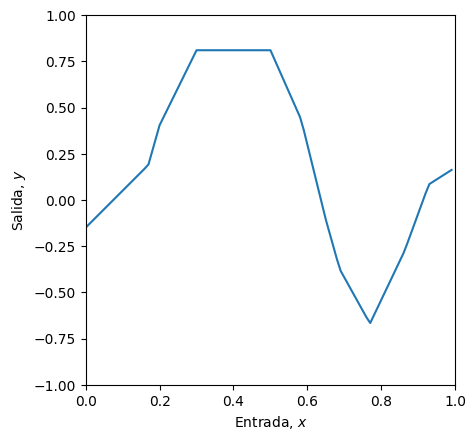

In [5]:
# Define los parámetros (nota: la primera dimensión de theta y phi se rellena para que los índices coincidan
# con la notación del libro)
theta = np.zeros([4,2])
psi = np.zeros([4,4])
phi = np.zeros([4,1])

theta[1,0] =  0.3 ; theta[1,1] = -1.0
theta[2,0]= -1.0  ; theta[2,1] = 2.0
theta[3,0] = -0.5  ; theta[3,1] = 0.65

psi[1,0] = 0.3;
psi[1,1] = 2.0; psi[1,2] = -1.0; psi[1,3]=7.0
psi[2,0] = -0.2;  psi[2,1] = 2.0; psi[2,2] = 1.2; psi[2,3]=-8.0
psi[3,0] = 0.3;  psi[3,1] = -2.3; psi[3,2] = -0.8; psi[3,3]=2.0
phi[0] = 0.0; phi[1] = 0.5; phi[2] = -1.5; phi [3] = 2.2

# Define un rango de valores de entrada
x = np.arange(0,1,0.01)

# Ejecuta la red neuronal
y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime \
    = shallow_1_1_3_3(x, ReLU, phi, psi, theta)

# Y luego trázala
plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime)

Para hacer: Para probar tu comprensión de esto, considera:

1.   ¿Qué pasaría si aumentamos $\psi_{1,0}$? Desplazamiento vertical

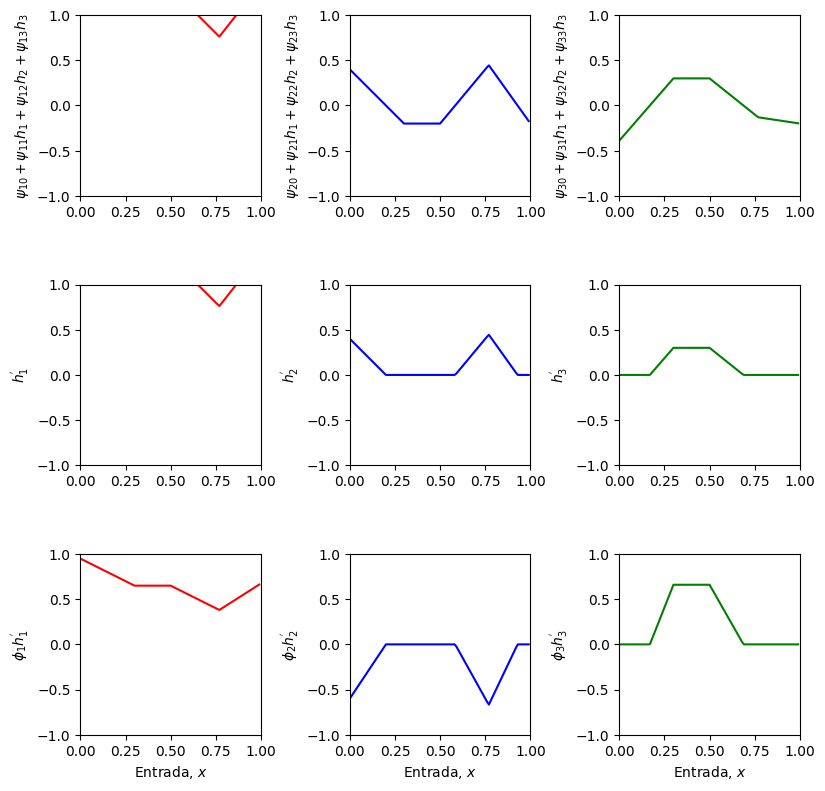

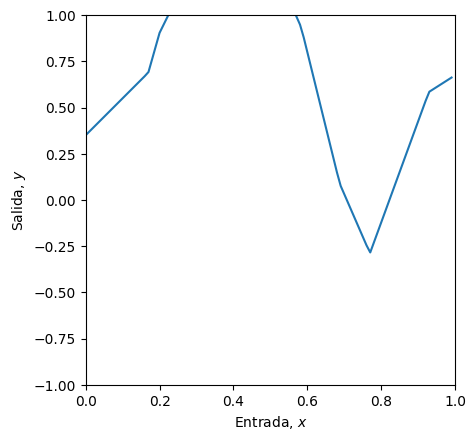

In [6]:
# Define los parámetros (nota: la primera dimensión de theta y phi se rellena para que los índices coincidan
# con la notación del libro)
theta = np.zeros([4,2])
psi = np.zeros([4,4])
phi = np.zeros([4,1])

theta[1,0] =  0.3 ; theta[1,1] = -1.0
theta[2,0]= -1.0  ; theta[2,1] = 2.0
theta[3,0] = -0.5  ; theta[3,1] = 0.65

psi[1,0] = 0.3;

psi[1,0] += 1;

psi[1,1] = 2.0; psi[1,2] = -1.0; psi[1,3]=7.0
psi[2,0] = -0.2;  psi[2,1] = 2.0; psi[2,2] = 1.2; psi[2,3]=-8.0


psi[3,0] = 0.3;  psi[3,1] = -2.3; psi[3,2] = -0.8; psi[3,3]=2.0
phi[0] = 0.0; phi[1] = 0.5; phi[2] = -1.5; phi [3] = 2.2

# Define un rango de valores de entrada
x = np.arange(0,1,0.01)

# Ejecuta la red neuronal
y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime \
    = shallow_1_1_3_3(x, ReLU, phi, psi, theta)

# Y luego trázala
plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime)

2.   ¿Qué pasaría si multiplicamos $\psi_{2,0}, \psi_{2,1}, \psi_{2,2},  \psi_{2,3}$ por -1? invierte en el segundo gráfico

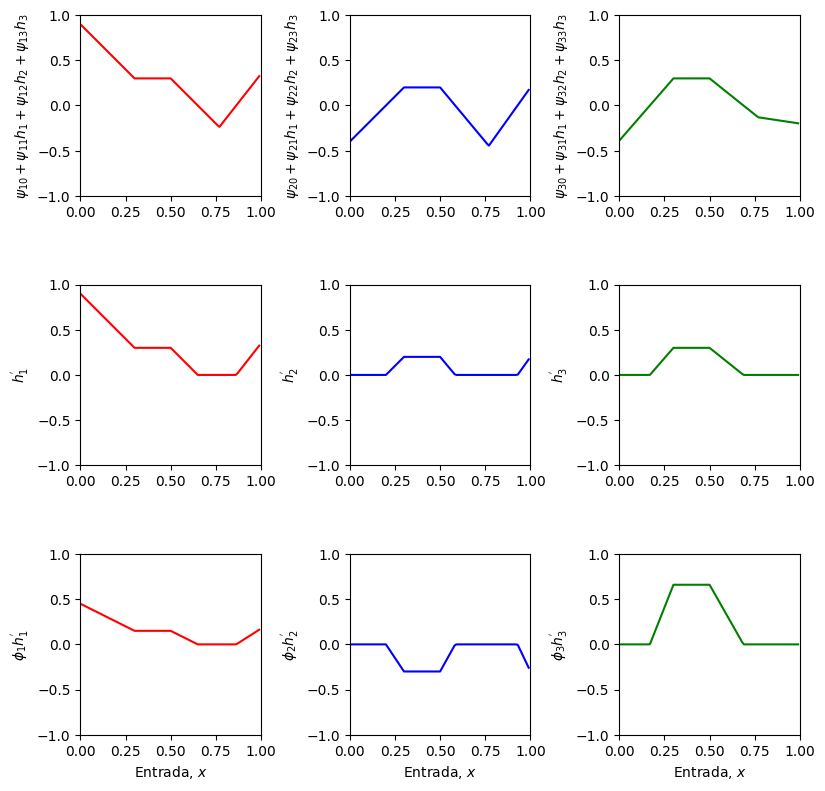

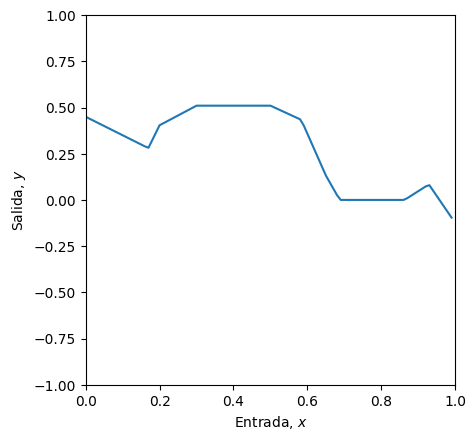

In [7]:
# Define los parámetros (nota: la primera dimensión de theta y phi se rellena para que los índices coincidan
# con la notación del libro)
theta = np.zeros([4,2])
psi = np.zeros([4,4])
phi = np.zeros([4,1])

theta[1,0] =  0.3 ; theta[1,1] = -1.0
theta[2,0]= -1.0  ; theta[2,1] = 2.0
theta[3,0] = -0.5  ; theta[3,1] = 0.65

psi[1,0] = 0.3;

psi[1,1] = 2.0; psi[1,2] = -1.0; psi[1,3]=7.0
psi[2,0] = -0.2;  psi[2,1] = 2.0; psi[2,2] = 1.2; psi[2,3]=-8.0

psi[2,0],psi[2,1],psi[2,2],psi[2,3] = psi[2,0] * -1,psi[2,1] * -1,psi[2,2] * -1,psi[2,3] * -1

psi[3,0] = 0.3;  psi[3,1] = -2.3; psi[3,2] = -0.8; psi[3,3]=2.0
phi[0] = 0.0; phi[1] = 0.5; phi[2] = -1.5; phi [3] = 2.2

# Define un rango de valores de entrada
x = np.arange(0,1,0.01)

# Ejecuta la red neuronal
y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime \
    = shallow_1_1_3_3(x, ReLU, phi, psi, theta)

# Y luego trázala
plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime)

3.  ¿Qué pasaría si establecemos $\phi_{3}$ en -1? disminuye la altura e invierte en el gráfico de phi3 * h3

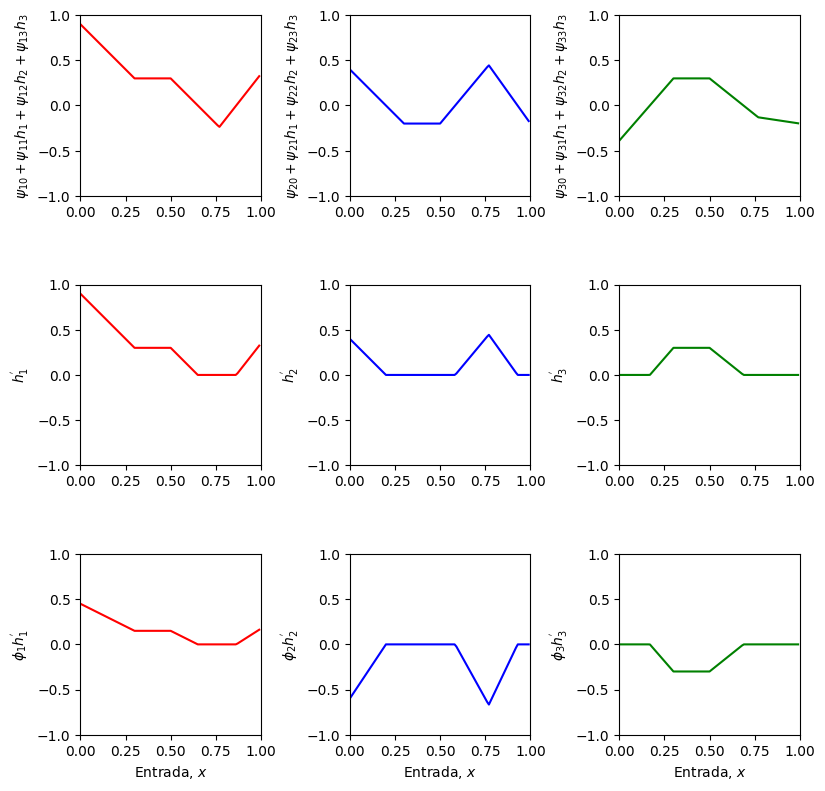

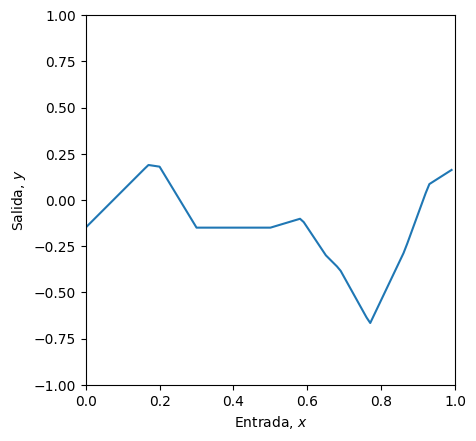

In [8]:
# Define los parámetros (nota: la primera dimensión de theta y phi se rellena para que los índices coincidan
# con la notación del libro)
theta = np.zeros([4,2])
psi = np.zeros([4,4])
phi = np.zeros([4,1])

theta[1,0] =  0.3 ; theta[1,1] = -1.0
theta[2,0]= -1.0  ; theta[2,1] = 2.0
theta[3,0] = -0.5  ; theta[3,1] = 0.65

psi[1,0] = 0.3;

psi[1,1] = 2.0; psi[1,2] = -1.0; psi[1,3]=7.0
psi[2,0] = -0.2;  psi[2,1] = 2.0; psi[2,2] = 1.2; psi[2,3]=-8.0

psi[3,0] = 0.3;  psi[3,1] = -2.3; psi[3,2] = -0.8; psi[3,3]=2.0
phi[0] = 0.0; phi[1] = 0.5; phi[2] = -1.5;

phi [3] = -1 #2.2

# Define un rango de valores de entrada
x = np.arange(0,1,0.01)

# Ejecuta la red neuronal
y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime \
    = shallow_1_1_3_3(x, ReLU, phi, psi, theta)

# Y luego trázala
plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime)

Puedes volver a ejecutar el código para ver si tenías razón.